# Hospital Readmission Analysis

## Problem Statement
Hospitals lose millions annually due to preventable 30-day readmissions.
This analysis explores 101,766 patient records to identify which patient 
groups are most at risk of being readmitted within 30 days of discharge.

## Dataset
UCI Diabetes 130-US Hospitals Dataset
- 101,766 patient records
- 50 features
- Time period: 1999-2008
- Source: University of California Irvine ML Repository

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn

In [1]:
import pandas as pd
df = pd.read_csv('diabetic_data.csv')
print(df.shape)
print(df['readmitted'].value_counts())

(101766, 50)
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## Step 1: Data Cleaning
First identifying missing values in the dataset.
Note: Missing values are hidden as '?' characters, not standard NaN values.

In [2]:
print(df.isnull().sum()[df.isnull().sum() > 0])

max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [3]:
import numpy as np
df_replaced = df.replace('?', np.nan)
print(df_replaced.isnull().sum()[df_replaced.isnull().sum() > 0])

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


## Step 2: Handling Missing Values

**Dropped columns** (too many missing values to be useful):
- weight: 97% missing
- max_glu_serum: 95% missing
- A1Cresult: 83% missing
- payer_code: 40% missing, not relevant to readmission

**Filled with 'Unknown':**
- race: 2,273 missing
- medical_specialty: 49,949 missing

**Result: 101,766 rows, 46 columns, 0 missing values**

In [4]:
df_replaced = df_replaced.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'payer_code'])
df_replaced['race'] = df_replaced['race'].fillna('Unknown')
df_replaced['medical_specialty'] = df_replaced['medical_specialty'].fillna('Unknown')
print(df_replaced.shape)
print(df_replaced.isnull().sum()[df_replaced.isnull().sum() > 0])

(101766, 46)
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [5]:
df_replaced['diag_1'] = df_replaced['diag_1'].fillna('Unknown')
df_replaced['diag_2'] = df_replaced['diag_2'].fillna('Unknown')
df_replaced['diag_3'] = df_replaced['diag_3'].fillna('Unknown')

print(df_replaced.isnull().sum().sum())


0


## Step 3: Understanding the Target Variable

Analyzing the distribution of our target variable - readmission status.
Key question: What percentage of patients are readmitted within 30 days?

In [7]:
df_replaced['readmitted'].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

# Key Insight 1:
* Only 11.16% of patients are readmitted within 30 days
* This is an imbalanced dataset - critical for analysis
* Our goal is to understand WHAT makes this 11% different

## Step 4: Exploratory Data Analysis

### Analysis 1: Readmission Rate by Age Group
Does age influence the likelihood of 30-day readmission?
Hypothesis: Older patients are more likely to be readmitted.

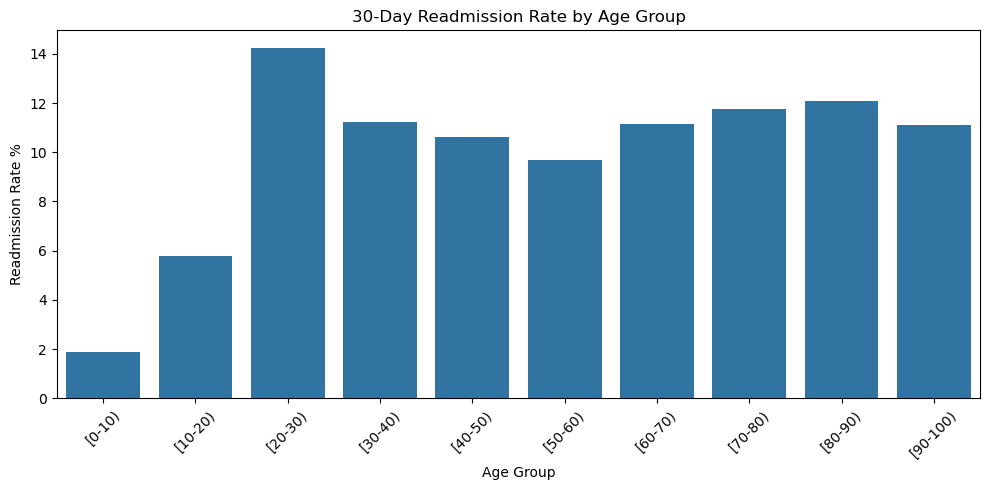

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

readmit_by_age = df_replaced.groupby('age')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_age.columns = ['age', 'readmission_rate']
readmit_by_age = readmit_by_age.sort_values('age')

plt.figure(figsize=(10,5))
sns.barplot(data=readmit_by_age, x='age', y='readmission_rate')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Key Insight 2:
* Contrary to expectation, 20-30 age group has highest 30-day readmission rate
* Possible reasons:
   - Less stable living conditions
   - Lower medication adherence
   - Less family support
   - Financial constraints affecting follow-up care

## Analysis 2: Readmission Rate by Time Spent in Hospital
Does a longer hospital stay indicate higher readmission risk?
Hypothesis: Patients who stay longer are sicker and more likely to return.

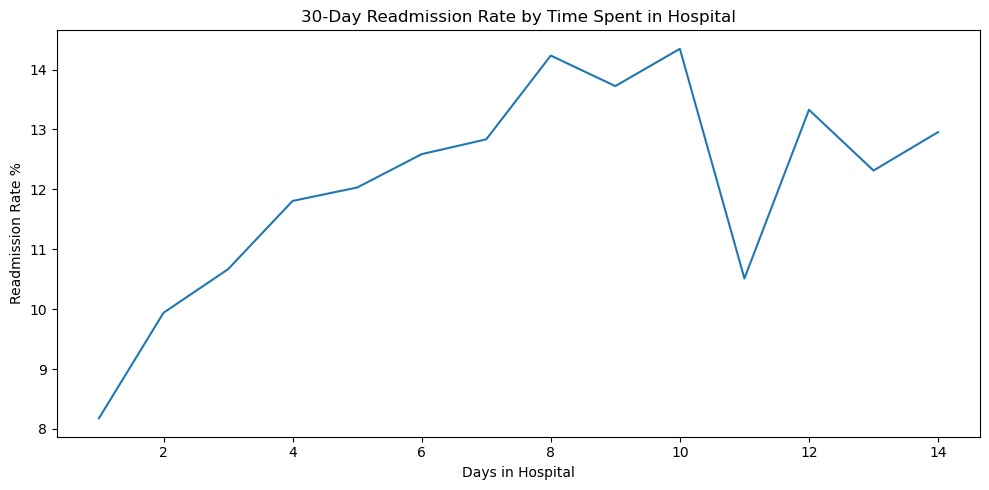

In [11]:
readmit_by_time = df_replaced.groupby('time_in_hospital')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_time.columns = ['time_in_hospital', 'readmission_rate']

plt.figure(figsize=(10,5))
sns.lineplot(data=readmit_by_time, x='time_in_hospital', y='readmission_rate')
plt.title('30-Day Readmission Rate by Time Spent in Hospital')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate %')
plt.tight_layout()
plt.show()

# Key Insight 3:
* Readmission rate generally increases with longer hospital stays
* Patients staying longer are sicker to begin with
* Slight drop at 11-12 days then increases again
* Possible reason: 11-12 day patients may receive more thorough care/monitoring
* before discharge compared to shorter stays

## Analysis 3: Readmission Rate by Number of Medications
Does the number of prescribed medications affect readmission risk?
Hypothesis: More medications indicate more complex conditions and higher readmission risk.

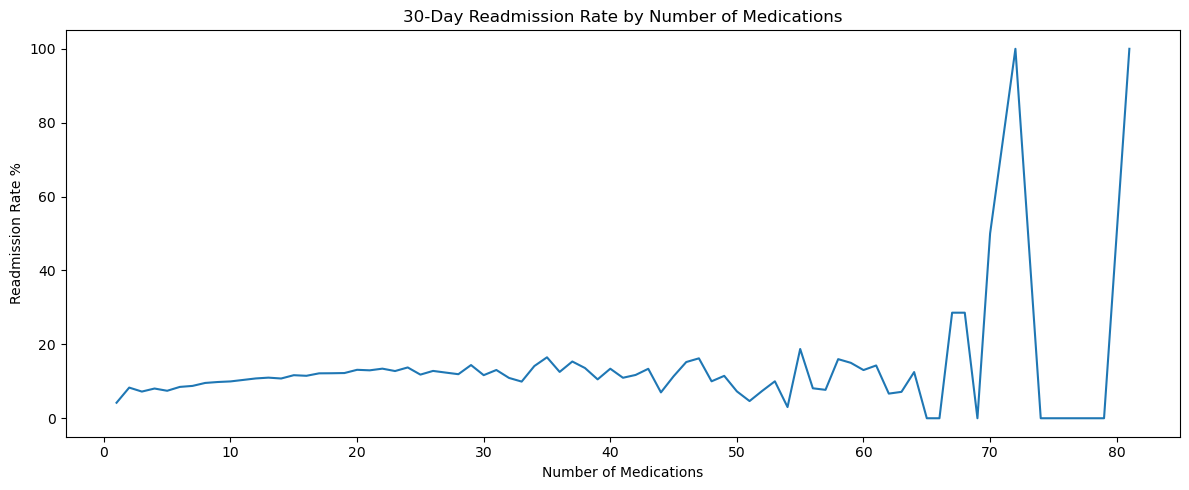

In [13]:
readmit_by_med = df_replaced.groupby('num_medications')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_med.columns = ['num_medications', 'readmission_rate']

plt.figure(figsize=(12,5))
sns.lineplot(data=readmit_by_med, x='num_medications', y='readmission_rate')
plt.title('30-Day Readmission Rate by Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate %')
plt.tight_layout()
plt.show()

# Key Insight 4:
* Higher number of medications correlates with higher readmission rate
* Possible reasons:
   - More medications = more complex medical condition
   - Higher chance of medication non-adherence with complex regimens
   - Drug interactions may cause complications leading to readmission
* Business Recommendation 1:
  - Hospitals should flag patients with high medication counts (15+)
  - for dedicated discharge counseling and follow-up calls

## Analysis 4: Readmission Rate by Previous Inpatient Visits
Do patients with a history of inpatient visits have higher readmission rates?
Hypothesis: Previous admissions indicate chronic conditions and higher readmission risk.

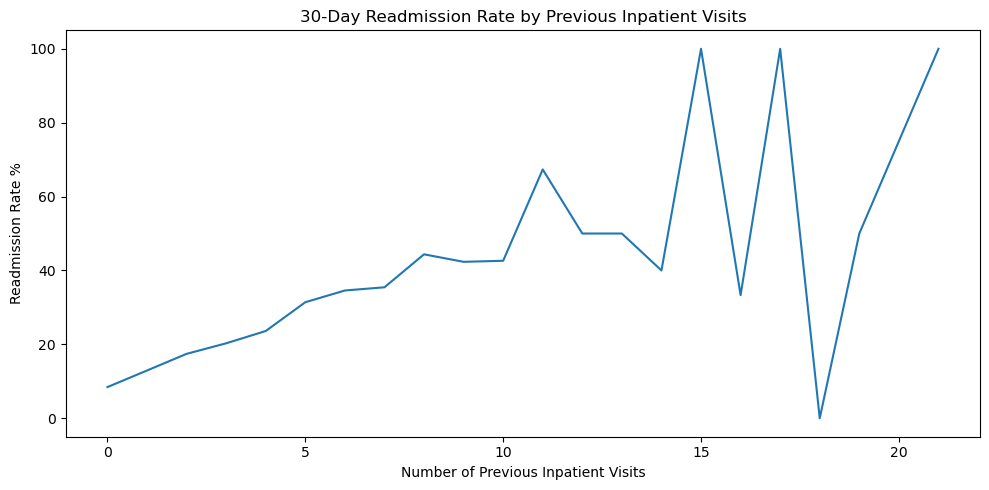

In [16]:
readmit_by_inpatient = df_replaced.groupby('number_inpatient')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_inpatient.columns = ['number_inpatient', 'readmission_rate']

plt.figure(figsize=(10,5))
sns.lineplot(data=readmit_by_inpatient, x='number_inpatient', y='readmission_rate')
plt.title('30-Day Readmission Rate by Previous Inpatient Visits')
plt.xlabel('Number of Previous Inpatient Visits')
plt.ylabel('Readmission Rate %')
plt.tight_layout()
plt.show()

# Key Insight 5:
Patients with more previous inpatient visits show steadily increasing 
readmission rates in the 0-10 visit range.

 - This is one of the strongest predictors found in this analysis.
 - A patient admitted 3+ times previously is significantly more likely 
   to return within 30 days.

**Business Recommendation 2:**
 - Assign dedicated case managers to patients with 3+ previous inpatient 
 - visits and schedule mandatory 7-day post discharge follow up calls.

## Analysis 5: Readmission Rate by Previous Emergency Visits
Do patients with history of emergency visits have higher readmission rates?
Hypothesis: Previous emergency visits indicate unstable health conditions.

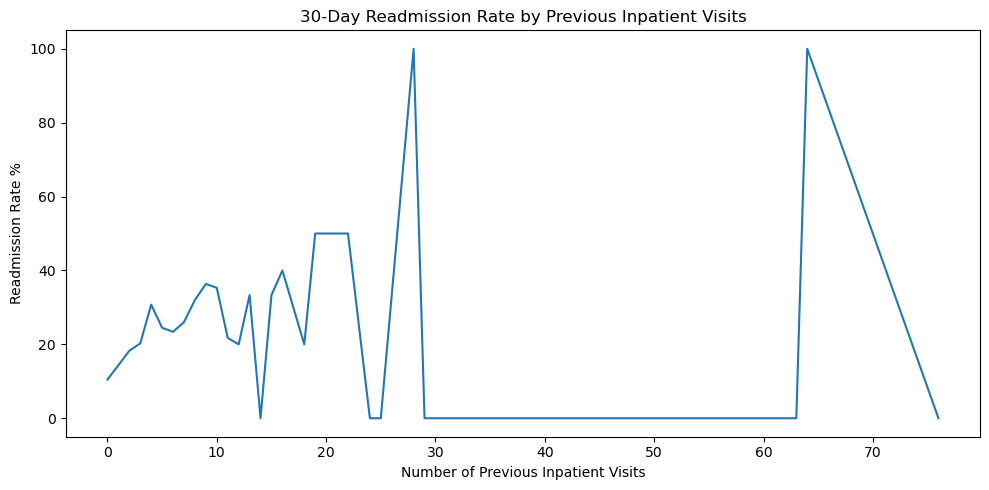

In [17]:
readmit_by_inpatient = df_replaced.groupby('number_emergency')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_inpatient.columns = ['number_inpatient', 'readmission_rate']

plt.figure(figsize=(10,5))
sns.lineplot(data=readmit_by_inpatient, x='number_inpatient', y='readmission_rate')
plt.title('30-Day Readmission Rate by Previous Inpatient Visits')
plt.xlabel('Number of Previous Inpatient Visits')
plt.ylabel('Readmission Rate %')
plt.tight_layout()
plt.show()

# Key Insight 6:
Previous emergency visits (0-5 range) show a clear increasing trend 
in readmission rates.
Data becomes noisy beyond 5 visits due to small sample sizes.

Patients with even 1-2 previous emergency visits are noticeably 
higher risk than patients with none.

## Analysis 6: Readmission Rate by Number of Lab Procedures
Do patients requiring more lab tests have higher readmission rates?
Hypothesis: More lab procedures indicate more serious medical conditions.

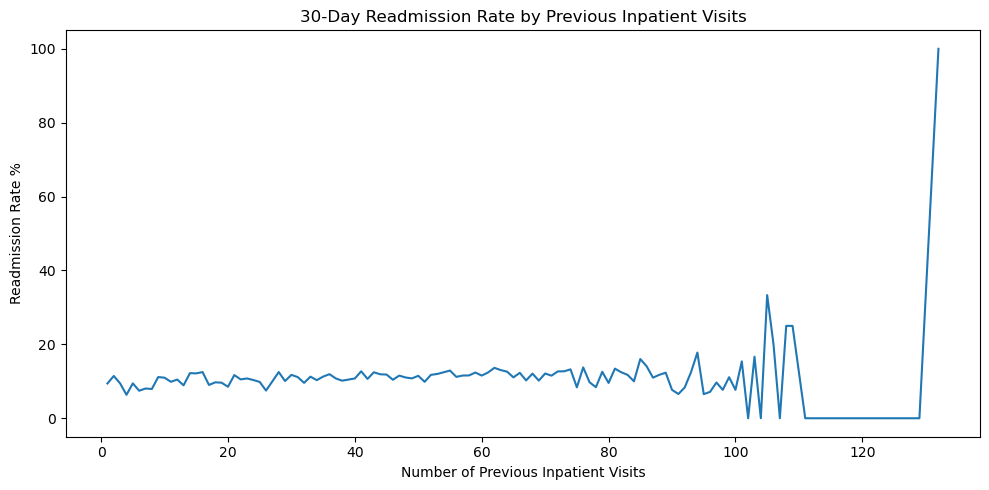

In [18]:
readmit_by_inpatient = df_replaced.groupby('num_lab_procedures')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
readmit_by_inpatient.columns = ['number_inpatient', 'readmission_rate']

plt.figure(figsize=(10,5))
sns.lineplot(data=readmit_by_inpatient, x='number_inpatient', y='readmission_rate')
plt.title('30-Day Readmission Rate by Previous Inpatient Visits')
plt.xlabel('Number of Previous Inpatient Visits')
plt.ylabel('Readmission Rate %')
plt.tight_layout()
plt.show()

# Key Insight 7:
 - Higher number of lab procedures correlates with higher readmission rates.
 - Patients requiring extensive testing are more critically ill and 
 - therefore higher readmission risk.

**Business Recommendation 3:**
 - Prioritize post-discharge follow up for patients with 50+ lab procedures 
 and 2+ previous emergency visits.

## Final Summary

### Dataset
- 101,766 patient records from 130 US hospitals (1999-2008)
- Only 11.16% of patients were readmitted within 30 days

### High Risk Patient Profile
Patients most likely to be readmitted within 30 days:
- Age group: 20-30 years
- Hospital stay: 7+ days
- Medications: 15+ prescribed
- Previous inpatient visits: 3+
- Previous emergency visits: 2+
- Lab procedures: 50+

### Business Recommendations
1. Flag patients with 15+ medications for dedicated discharge counseling
2. Assign case managers to patients with 3+ previous inpatient visits
3. Mandatory follow up calls for patients with 50+ lab procedures

### Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn

### Data Source
UCI Machine Learning Repository - Diabetes 130-US Hospitals Dataset